In [1]:
import pandas as pd

# ------------------------------
# Load the dataset
# ------------------------------
data_path = r"C:\Users\LENOVO\Desktop\Data Science\DS course\src\MD_agric_exam-4313.csv"
data = pd.read_csv(data_path)

# Quick check
print(data.head())
print(data.columns)

# ------------------------------
# Example 1: Maximum annual yield for 'wheat'
# ------------------------------
max_wheat_yield = round(data.loc[data['Crop_type'] == 'wheat', 'Annual_yield'].max(), 2)
print("Maximum wheat yield:", max_wheat_yield)

# ------------------------------
# Example 2: Total rainfall for crops with avg pollution > 0.2
# ------------------------------
pollution_avg = data.groupby('Crop_type')['Pollution_level'].mean()
crops_high_pollution = pollution_avg[pollution_avg > 0.2].index
total_rainfall = data.loc[data['Crop_type'].isin(crops_high_pollution), 'Rainfall'].sum()
print("Total rainfall for crops with avg pollution > 0.2:", total_rainfall)

# ------------------------------
# Example 3: Temperature range per Field_ID
# ------------------------------
def temp_range(field_id):
    row = data[data['Field_ID'] == field_id]
    if not row.empty:
        return row['Max_temperature_C'].values[0] - row['Min_temperature_C'].values[0]
    return None

for fid in [1458, 1895, 5443]:
    print(f"Temperature range for Field_ID {fid}: {temp_range(fid)}")

# ------------------------------
# Example 4: Total plot size for pH < 5.5
# ------------------------------
total_plot_size = data.loc[data['pH'] < 5.5, 'Plot_size'].sum()
print("Total plot size for pH < 5.5:", total_plot_size)

# ------------------------------
# Example 5: Filter by temperature conditions
# ------------------------------
filtered = data[(data['Min_temperature_C'] < -5) & (data['Max_temperature_C'] > 30)]
print("Number of rows with Min < -5 and Max > 30:", filtered.shape[0])

# ------------------------------
# Example 6: Crop with lowest avg min temperature
# ------------------------------
crop_min_temp = data.groupby('Crop_type')['Min_temperature_C'].mean().idxmin()
print("Crop with lowest avg min temperature:", crop_min_temp)

# ------------------------------
# Example 7: String from Max_temperature_C and Crop_type
# ------------------------------
max_temp_mode = str(int(data['Max_temperature_C'].mode()[0]))[:2]  # first 2 or 3 digits
crop_type_mode = data['Crop_type'].mode()[0][-3:]  # last 3 letters
final_string = max_temp_mode + crop_type_mode
print("Concatenated string:", final_string)


   Field_ID  Elevation  Rainfall  Min_temperature_C  Max_temperature_C  \
0      1162  494.95615    1507.6               -5.4               31.0   
1      5108  663.73390     581.0               -4.7               30.9   
2      3504  396.87990    1715.1               -6.1               31.7   
3      5351  594.80370    1748.0               -4.3               33.6   
4       905  609.49800    1395.8               -4.5               31.3   

         pH  Pollution_level  Plot_size  Annual_yield Crop_type  
0  6.859436         0.007034        3.6      1.617421    coffee  
1  5.603219         0.289643        4.2      2.532497    potato  
2  5.774116         0.000409        2.6      1.262207    banana  
3  6.477415         0.088777        7.9      4.351564     wheat  
4  5.419586         0.050023       10.8      5.034791   cassava  
Index(['Field_ID', 'Elevation', 'Rainfall', 'Min_temperature_C',
       'Max_temperature_C', 'pH', 'Pollution_level', 'Plot_size',
       'Annual_yield', 'Crop

In [2]:
import numpy as np
import pandas as pd

# Load your CSV
data_path = r"C:\Users\LENOVO\Desktop\Data Science\DS course\src\MD_agric_exam-4313.csv"
data = pd.read_csv(data_path)

# Step 1: Calculate the median plot size
median_plot_size = data['Plot_size'].median()

# Step 2: Filter plots larger than median
large_plots = data[data['Plot_size'] > median_plot_size]

# Step 3: Calculate standard deviation of Rainfall
std_rainfall = np.round(np.std(large_plots['Rainfall'], ddof=0), 2)  # population std
# If you want sample std, use ddof=1

print("Standard deviation of Rainfall for plots larger than median:", std_rainfall)


Standard deviation of Rainfall for plots larger than median: 469.62


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_10424\2514481262.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Elevation_category', y='Annual_yield', data=data, palette='Set2')


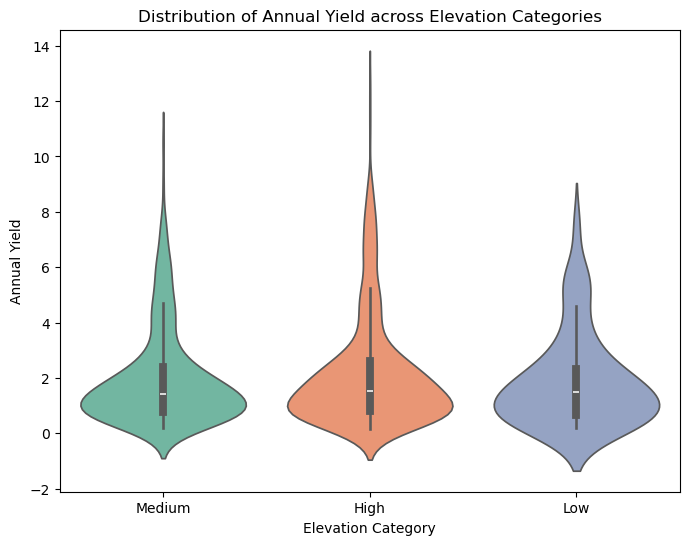

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load your dataset
data_path = r"C:\Users\LENOVO\Desktop\Data Science\DS course\src\MD_agric_exam-4313.csv"
data = pd.read_csv(data_path)

# Categorize elevation into Low, Medium, High
def elevation_category(elev):
    if elev < 300:
        return 'Low'
    elif 300 <= elev <= 600:
        return 'Medium'
    else:
        return 'High'

data['Elevation_category'] = data['Elevation'].apply(elevation_category)

# Create violin plot
plt.figure(figsize=(8,6))
sns.violinplot(x='Elevation_category', y='Annual_yield', data=data, palette='Set2')
plt.title('Distribution of Annual Yield across Elevation Categories')
plt.xlabel('Elevation Category')
plt.ylabel('Annual Yield')
plt.show()


In [5]:
unique_crops = data['Crop_type'].unique()
print(unique_crops)


['coffee' 'potato' 'banana' 'wheat' 'cassava' 'maize' 'tea' 'rice']


In [6]:
def recursive_crop_sum(crops):
    if len(crops) == 0:       # base case
        return 0
    return len(crops[0]) + recursive_crop_sum(crops[1:])


In [7]:
total_sum = recursive_crop_sum(unique_crops)
print(total_sum)


42


In [8]:
from scipy.stats import ttest_ind

# Filter the two crop groups
coffee_yield = data[data['Crop_type'] == 'coffee']['Annual_yield'].dropna()
banana_yield = data[data['Crop_type'] == 'banana']['Annual_yield'].dropna()

# Perform an independent t-test
t_stat, p_value = ttest_ind(coffee_yield, banana_yield, equal_var=False)

print("P-value:", round(p_value, 3))


P-value: 0.598


In [9]:
# 1. Most common Max_temperature_C → take first 3 digits
max_temp_mode = data['Max_temperature_C'].mode()[0]
first_three = str(int(max_temp_mode))[:3]   # convert to string & take first 3 characters

# 2. Least common Crop_type → take the last 3 letters
crop_counts = data['Crop_type'].value_counts()
least_common_crop = crop_counts.index[-1]   # last one = least common
last_three = least_common_crop[-3:]         # last 3 letters

# 3. Concatenate
result = first_three + last_three
print(result)


30ice
